In [15]:
from pathlib import Path
import matplotlib.pyplot as plt

from mt_structure_classification.dataset.image_files_indexing import build_pairs_dataframe_flexible
from mt_structure_classification.utils.image_processing import load_pair_image_2d  # if you have it; otherwise see note below
from mt_structure_classification.utils.GUV_mt_segmentation import (
    segment_guv_hough_circles,
    DEFAULT_HOUGH_SCALES,
)
from mt_structure_classification.utils.colormap_definition import make_repeated_tab10_cmap


root = Path("/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001")

df = build_pairs_dataframe_flexible(root)
print("pairs:", len(df))
row_id = 69  # pick one you know works

guv_path = Path(df.loc[row_id, "GUV_folder_path"]) / df.loc[row_id, "GUV_file_name"]
mt_path  = Path(df.loc[row_id, "MT_folder_path"])  / df.loc[row_id, "MT_file_name"]

# --- load 2D images ---
guv_img, mt_img = load_pair_image_2d(guv_path, mt_path)  # returns (H,W) float/uint

# --- run circle detection ---
out = segment_guv_hough_circles(
    guv_img,
    mt_img=mt_img,
    hough_scales=DEFAULT_HOUGH_SCALES,
    dp=1.1,
    mt_bg_int=120.0,          # use your constants
    mt_std_threshold=15.0,    # your filter threshold
)

circles = out["good_circles"]  # or whatever key you returned
print("kept circles:", len(circles))


[MISSING PAIR]
  GUV: /mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/1_10 Tau_Tubulin/Date 3/GUV/Image 4_GUV.TIF
  MT : /mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/1_10 Tau_Tubulin/Date 3/Microtubule/Image 4_MT.TIF

[MISSING PAIR]
  GUV: /mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/1_10 Tau_Tubulin/Date 5/GUV/1 uM tau mt encap guv53_w1561.TIF
  MT : /mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/1_10 Tau_Tubulin/Date 5/Microtubule/1 uM tau mt encap guv53_w2640.TIF

[MISSING PAIR]
  GUV: /mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/2_10 Tau_Tubulin/Date 4/GUV/IMAGE 31_w2561.TIF
  MT : /mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/2_10 Tau_Tubu

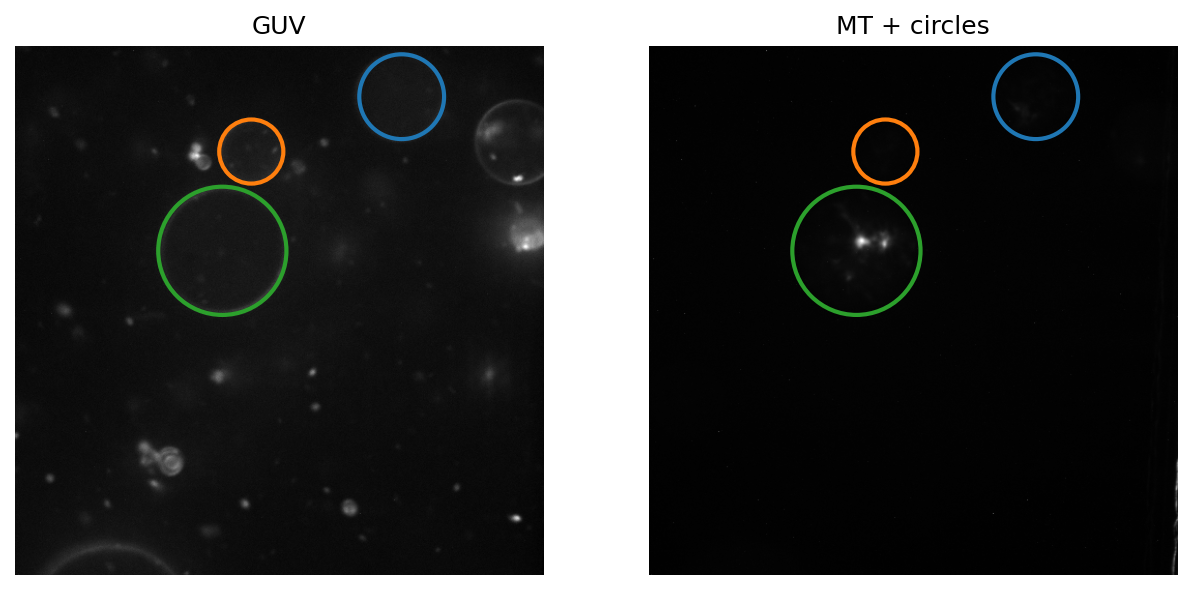

In [16]:

cmap = make_repeated_tab10_cmap(n_labels=max(200, len(circles) + 1))

# --- visualize ---
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=150)
ax[0].imshow(guv_img, cmap="gray")
ax[0].set_title("GUV")
ax[0].axis("off")

ax[1].imshow(mt_img, cmap="gray")
ax[1].set_title("MT + circles")
ax[1].axis("off")

# circles assumed shape (N, 3): (x, y, r)
for i, (x, y, r) in enumerate(circles, start=1):
    color = cmap(i)  # RGBA tuple
    ax[0].add_patch(plt.Circle((x, y), r, fill=False, linewidth=2, color=color))
    ax[1].add_patch(plt.Circle((x, y), r, fill=False, linewidth=2, color=color))

plt.show()



In [ ]:
from mt_structure_classification.utils.GUV_mt_segmentation import get_cellpose_model, segment_with_cellpose

# ---- init cellpose ----
gpu = True
model = get_cellpose_model(model_type="cyto3", gpu=gpu)

cellpose_kwargs = dict(
    # examples you may tune
    flow_threshold=0.4,
    cellprob_threshold=0.0,
)
diameter = None
channels = (1,2)  # single-channel grayscale

mask = segment_with_cellpose(model, guv_img_normed, mt_img_normed, diameter=diameter, channels=channels, **cellpose_kwargs)

